In [1]:
    
from pathlib import Path
import numpy as np
from gauss_newton_math import *
from systems import *
from utils import plot_solution
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
import time as tm_module
import jax.numpy as jnp
from casadi import SX, reshape
from dataclasses import dataclass
from acados_template import AcadosOcp, AcadosOcpSolver, AcadosModel
from casadi import SX, vertcat, tan, cos, sin, mtimes, fmax, fmin
import math
import sys
import os
working_directory = Path(os.getcwd()) / 'codegen'
print("working_directory:", working_directory)
sys.path.insert(0, str(working_directory))
import mhe.mhe_kinematic_model as mhe_kinematic_model
from params import MheParams


working_directory: /home/iachichkanov/autotech/lateral-controler/identification/codegen


In [2]:
mhe_horizont = 100
ts = 0.02
Q0_mhe = np.diag([1])
P0_mhe = np.diag([10, 150])
wheel_base = 2.65
state_noise_stds_mhe = np.array([0.001])
R_mhe = np.diag([0.1])   #x
Q_mhe = np.diag(1. / state_noise_stds_mhe**2) # w_noise
use_offset = 0
delay = 0  #is not used
if (not use_offset):
    P0_mhe = P0_mhe[:1, :1]   #only GR

mhe_params = MheParams(ts,
                        mhe_horizont,
                        Q0_mhe,
                        P0_mhe,
                        Q_mhe,
                        R_mhe,
                        wheel_base,
                        use_offset,
                        delay)
mhe_params.print()
acados_solver_mhe = mhe_kinematic_model.set_ocp_problem(mhe_params, 'bicycle_mhe', working_directory/'mhe_codegen')                        
# export_mhe_solver(mhe_params, "bycicle_mhe")

dt:  0.02
mhe_horizont:  100
noise_peanlty_w:  [[1000000.]]
state_prior_q0:  [[1]]
params_prior_p0:  [[10]]
measurements_residual_r:  [[0.1]]
wheelbase:  2.65
use_offset:  0
delay:  0
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this 

In [3]:
from matplotlib.gridspec import GridSpec

def prepare_sintetic_data(system: SystemJacobian, c0, theta, time_intervals, N_measurement, continious = False, sigma = 0.01):
    def generate_sintetic_data(
        system,
        c0_true,
        theta_true,
        t_s = 0,
        t_f = 8,
        N_measurement = 500,
        sigma = 1e-3):

        N = system.STATE_LENGTH
        mean = np.zeros(N)
        cov = np.diag(N*[sigma])
        noise = np.random.multivariate_normal(mean, cov, N_measurement)
        t_eval_measurements = np.linspace(t_s, t_f, N_measurement) 
        solution = system.get_solution(c0_true, theta_true, t_eval_measurements) 
        
        #state_full = solution[1][0:STATE_LENGTH] +  (np.random.random(solution[1][0:STATE_LENGTH].shape) - 0.5)*sigma
        return t_eval_measurements, solution.T + noise

    STATE_LENGTH, THETA_LENGTH, MEAS_LEN = system.get_dimentions()
    assert len(c0) == STATE_LENGTH
    assert len(theta) == THETA_LENGTH

    state_measured_batches = []
    state_full_batches = []
    t_eval_measurements_batches = []


    for (t_s, t_f) in time_intervals:
        t_eval_measurements, state_full  = generate_sintetic_data(system, c0_true=c0 , N_measurement = N_measurement, theta_true = theta, t_s = t_s, t_f = t_f, sigma = sigma)
        state_measured = np.zeros((len(state_full), MEAS_LEN))
        for i, state in enumerate(state_full):
            state_measured[i] = system.h_x(state, t_eval_measurements[i], theta)
        
        t_eval_measurements_batches.append(t_eval_measurements)
        state_measured_batches.append(state_measured)
        state_full_batches.append(state_full)
        if(continious):
            c0 = state_full[-1]
    return t_eval_measurements_batches, state_measured_batches, state_full_batches


    

In [4]:

class KinematicBycicle(System):
    def __init__(self):
        self.state = [SX.sym('psi')]
        self.input_signals = [SX.sym('u'), SX.sym('v')]
        self.params = [SX.sym('GR'), SX.sym('offset')]
        self.wheelbase = 5.115

    def get_system(self):
        GR, offset  = self.params
        steering, v  = self.input_signals 
        w = v * np.tan(GR*(steering + offset))/ self.wheelbase
        psi_dot = w 
        return vertcat(*self.state), vertcat(*self.input_signals), vertcat(*self.params), vertcat( psi_dot) 

    def get_input_signals(self, t):
        w = 0.7
        steering = 0.8 * math.cos(t*0.25*w) * math.sin(w*t) 
        if(t > 200):
            steering = 0
        return [steering, 10.0]
    
    def observation(self):
        psi = self.state[0]
        observed = vertcat(psi)
        #observed = vertcat( wz)
        return observed 
        
sym_object = KinematicBycicle()
theta_true = np.array([0.05, 0.03])
c0 = np.array([0]) 
theta = theta_true

system = SystemJacobian(sym_object)

In [5]:
T_f = mhe_params.dt*mhe_params.mhe_horizont
N_measurement = mhe_params.mhe_horizont



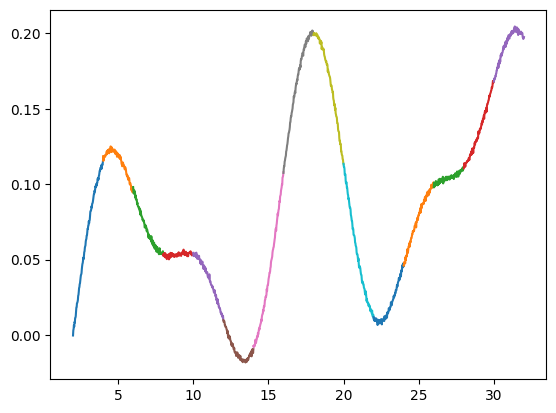

In [6]:
time_intervals = []
t0 = 0
for i in range(15):
    time_intervals.append((t0 + T_f, t0 + 2*T_f))
    t0 += T_f

sigma =1e-6
t_eval_measurements_batches, state_measured_batches, state_full_batches = prepare_sintetic_data(system, c0, theta_true, time_intervals, sigma = sigma, continious = 1, N_measurement = N_measurement)

t_eval_batches_debug, state_measured_batches_debug, state_full_batches_debug = prepare_sintetic_data(system, c0, theta_true, time_intervals, sigma = 0*5e-5, continious = 1, N_measurement = N_measurement * 10)

def get_measurements_sintetic_data(batch: int):
    simU = np.zeros((N_measurement, 2))
    for i, t in enumerate(t_eval_measurements_batches[batch]):
        simU[i, :] = sym_object.get_input_signals(t)
    simY = state_measured_batches[batch]
    return simU, simY, t_eval_measurements_batches[batch]

for i in range(15):
    simU, simY, t = get_measurements_sintetic_data(i)
    plt.plot(t, simY)
    #plt.plot(t, simU)

    

In [7]:
# from data_utils import init_log_reader, LogReader
# from scipy import interpolate
# path = Path("/home/iachichkanov/sda_context/logs/shattle_identification/skipad_ballast/")
# data_storage = LogReader(path)
# data_storage.add_batch("CG_SteeringFront_src00.csv", "SteeringAngleFront", "steering", False)

# data_storage.add_batch("_pose_aligned.csv", "vx", "vx", True)
# data_storage.add_batch("_pose_aligned.csv", "vy", "vy", True)
# data_storage.add_batch("_pose_aligned.csv", "vz", "vz", True)
# data_storage.add_batch("_pose_aligned.csv", "wz", "wz", True)
# data_storage.add_batch("_pose_aligned.csv", "yaw", "yaw", True)

In [8]:
# time_pose = data_storage.get_time('vx')
# time_pose = time_pose[np.where(np.logical_and.reduce([time_pose >= data_storage.t1,  time_pose < data_storage.t2]))]
# f_vx = data_storage.get_f_interp("vx")
# f_wz = data_storage.get_f_interp("wz")
# f_vy = data_storage.get_f_interp("vy")
# f_steering = data_storage.get_f_interp("steering")
# f_yaw = data_storage.get_f_interp("yaw")
# f_yaw = interpolate.interp1d(time_pose, np.unwrap(np.deg2rad(f_yaw(time_pose))))
# time_pose = time_pose[np.where(np.logical_and.reduce([time_pose >= data_storage.t1,  time_pose < 400, f_vx(time_pose) > 0.3]))]


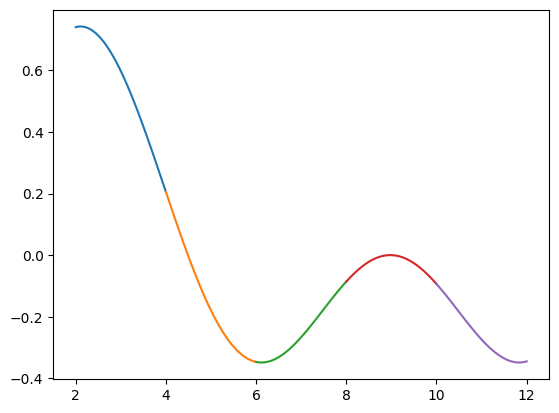

In [9]:

def get_measurements_data(batch: int, sintetic: bool = True):
    if(sintetic):
        return get_measurements_sintetic_data(batch)
    t1 = time_pose[0] + T_f * batch
    t_batch = np.linspace(t1, t1 + T_f, N_measurement)

    simU = np.zeros((N_measurement, 2))
    for i, t in enumerate(t_batch):
        simU[i, :] = [np.deg2rad(f_steering(t)), f_vx(t)]
    simY = f_yaw(t_batch)[:, np.newaxis]
    return simU, simY, t_batch

for i in range(5):
    simU, simY, t = get_measurements_data(i)
    #plt.plot(t, simY)
    plt.plot(t, simU[:, 0])

    


In [10]:
# plt.plot(time_pose, f_yaw(time_pose))
# plt.plot(time_pose, np.deg2rad(f_steering(time_pose)))
#plt.plot(time_pose, f_vx(time_pose))
T_f

2.0

In [11]:


def set_solver(acados_solver_mhe: AcadosOcpSolver, simY: np.array,  simU: np.array, initial_x0: np.array, initial_theta: np.array) -> None :
    model_mhe = acados_solver_mhe.acados_ocp.model
    nx_augmented = model_mhe.x.rows()
    # nw = model_mhe.u.rows()
    # nu = model_mhe.p.rows()
    nx = len(initial_x0)
    #x0_bar = np.array([0, 1])


    x_prior = np.hstack((initial_x0, initial_theta))
    p_ext_0 = np.hstack((simU[0, :], simY[0, :], x_prior))
    acados_solver_mhe.set(0, "p", p_ext_0)
    # set initial guess to x0_bar
    #acados_solver_mhe.set(0, "x", x_prior)

    for j in range(1, N_measurement):   
        # set measurements and controls
        p_ext = np.hstack((simU[j, :], simY[j, :], x_prior))
        acados_solver_mhe.set(j, "p", p_ext)


def get_estimated_data(acados_solver_mhe: AcadosOcpSolver):
    model_mhe = acados_solver_mhe.acados_ocp.model
    param_length = model_mhe.param_length
    nx = model_mhe.x.rows() - param_length
    simXest = np.zeros((N_measurement + 1, nx))
    simWest = np.zeros((N_measurement, nx))
    sim_param_est = np.zeros((N_measurement + 1, param_length))

    for i in range(N_measurement):
        x_augmented = acados_solver_mhe.get(i, "x")
        simXest[i,:] = x_augmented[0:nx]
        sim_param_est[i,:] = x_augmented[nx:nx + param_length]
        simWest[i,:] = acados_solver_mhe.get(i, "u")

    x_augmented = acados_solver_mhe.get(N_measurement, "x")
    simXest[N_measurement,:] = x_augmented[0:nx]
    sim_param_est[N_measurement,:] = x_augmented[nx:]
    return simXest, simWest, sim_param_est
 

In [12]:
simU, simY, t_batch = get_measurements_data(0)
simU

array([[ 0.74056367, 10.        ],
       [ 0.74133327, 10.        ],
       [ 0.74194104, 10.        ],
       [ 0.74238719, 10.        ],
       [ 0.74267199, 10.        ],
       [ 0.74279575, 10.        ],
       [ 0.74275881, 10.        ],
       [ 0.74256156, 10.        ],
       [ 0.74220444, 10.        ],
       [ 0.74168791, 10.        ],
       [ 0.7410125 , 10.        ],
       [ 0.74017876, 10.        ],
       [ 0.73918729, 10.        ],
       [ 0.73803873, 10.        ],
       [ 0.73673376, 10.        ],
       [ 0.73527309, 10.        ],
       [ 0.7336575 , 10.        ],
       [ 0.73188777, 10.        ],
       [ 0.72996476, 10.        ],
       [ 0.72788934, 10.        ],
       [ 0.72566243, 10.        ],
       [ 0.72328498, 10.        ],
       [ 0.720758  , 10.        ],
       [ 0.71808252, 10.        ],
       [ 0.71525961, 10.        ],
       [ 0.71229039, 10.        ],
       [ 0.70917598, 10.        ],
       [ 0.70591759, 10.        ],
       [ 0.70251643,

In [13]:
acados_solver_mhe
simU, simY, t_batch = get_measurements_data(0)
initial_x0 = simY[0]
initial_theta = np.array([1/10, 0.0])
if(not mhe_params.use_offset):
    initial_theta = initial_theta[1:]
set_solver(acados_solver_mhe, simY, simU, initial_x0, initial_theta)
simXest, simWest, sim_param_est = get_estimated_data(acados_solver_mhe)

[-0.00025345] [0.]
[0.09743355] [0.0185067]
[0.09559913] [0.01870956]
[0.05477211] [0.01997305]
[0.05075302] [0.01990238]
[0.0124755] [0.02052154]
[-0.01130675] [0.02089016]
[0.10431749] [0.02512819]
[0.19867979] [0.02654037]
[0.10919908] [0.02507211]
[0.01145688] [0.02428646]
[0.044524] [0.02519256]
[0.09679901] [0.0262988]
[0.10772055] [0.026423]
[0.16806529] [0.02732328]


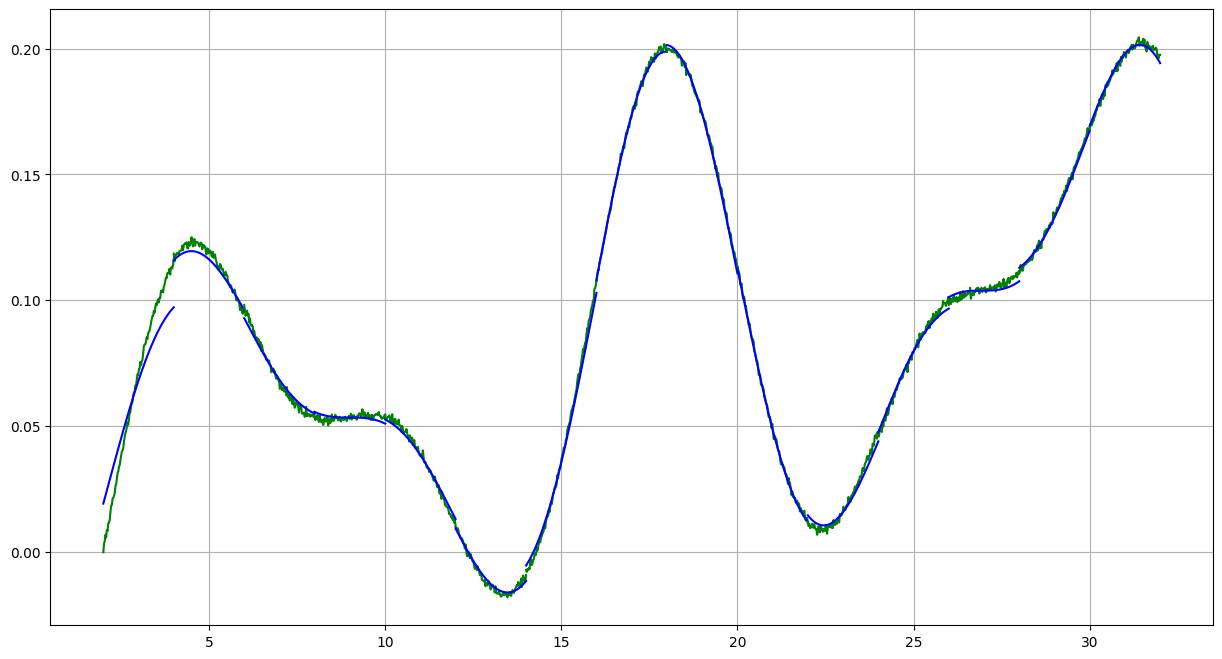

In [24]:
# solve mhe problem
fig = plt.figure(figsize = (15, 8))
plt.grid(True)
initial_theta = np.array([1/10, 0.0])
if(not mhe_params.use_offset):
    initial_theta = initial_theta[1:]
# initial_theta = np.array([theta_true[0], theta_true[1]])
THETA_EST = []
MEAN_PARAM = []
TRAJ_DIST = np.array([])
alpha  = 0.0
for iter in range(15):
    THETA_EST.append(initial_theta)
    simU, simY, t_batch = get_measurements_data(iter)
    if(iter == 0):
        initial_x0 = simY[0]

    MEAN_PARAM.append(np.mean(simU[:, 1]))
    print(initial_x0, initial_theta)
    set_solver(acados_solver_mhe, simY, simU, initial_x0, initial_theta)
    status = acados_solver_mhe.solve()

    if status != 0:
        raise Exception(f'acados returned status {status}.')
    simXest, simWest, sim_param_est = get_estimated_data(acados_solver_mhe)
    initial_x0 = simXest[-1]
    #initial_theta = sim_param_est[-1]
    initial_theta = alpha * initial_theta + (1 - alpha) * sim_param_est[-1]
    plt.plot(t_batch, simY, c ='g')  
    #plt.plot(t_batch, simU[:, 1], c ='r') 
    plt.plot(t_batch, simXest[:-1], c = 'b')
    diff = (simXest[:-1] -simY)
    if(iter == 0):
        TRAJ_DIST = diff
    else:
        TRAJ_DIST = np.hstack((TRAJ_DIST, diff))


In [15]:
acados_solver_mhe.get_hessian_block(2)

array([[ 4.00000000e+04,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.00000000e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -1.46078014e-05]])

In [50]:
acados_solver_mhe.get_hessian_block(2)

array([[4.00000000e+04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.00000000e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.53866841e-04, 2.53866841e-05],
       [0.00000000e+00, 0.00000000e+00, 2.53866841e-05, 2.53866841e-06]])

In [25]:
acados_solver_mhe.get_last_qp().keys()

dict_keys(['B_00', 'B_01', 'B_02', 'B_03', 'B_04', 'B_05', 'B_06', 'B_07', 'B_08', 'B_09', 'B_10', 'B_11', 'B_12', 'B_13', 'B_14', 'B_15', 'B_16', 'B_17', 'B_18', 'B_19', 'B_20', 'B_21', 'B_22', 'B_23', 'B_24', 'B_25', 'B_26', 'B_27', 'B_28', 'B_29', 'B_30', 'B_31', 'B_32', 'B_33', 'B_34', 'B_35', 'B_36', 'B_37', 'B_38', 'B_39', 'B_40', 'B_41', 'B_42', 'B_43', 'B_44', 'B_45', 'B_46', 'B_47', 'B_48', 'B_49', 'A_00', 'A_01', 'A_02', 'A_03', 'A_04', 'A_05', 'A_06', 'A_07', 'A_08', 'A_09', 'A_10', 'A_11', 'A_12', 'A_13', 'A_14', 'A_15', 'A_16', 'A_17', 'A_18', 'A_19', 'A_20', 'A_21', 'A_22', 'A_23', 'A_24', 'A_25', 'A_26', 'A_27', 'A_28', 'A_29', 'A_30', 'A_31', 'A_32', 'A_33', 'A_34', 'A_35', 'A_36', 'A_37', 'A_38', 'A_39', 'A_40', 'A_41', 'A_42', 'A_43', 'A_44', 'A_45', 'A_46', 'A_47', 'A_48', 'A_49', 'b_00', 'b_01', 'b_02', 'b_03', 'b_04', 'b_05', 'b_06', 'b_07', 'b_08', 'b_09', 'b_10', 'b_11', 'b_12', 'b_13', 'b_14', 'b_15', 'b_16', 'b_17', 'b_18', 'b_19', 'b_20', 'b_21', 'b_22', 'b_23

In [44]:
simXest

array([[0.1692523 ],
       [0.16998505],
       [0.17071524],
       [0.17144263],
       [0.17216699],
       [0.17288809],
       [0.17360567],
       [0.1743195 ],
       [0.17502934],
       [0.17573494],
       [0.17643607],
       [0.17713248],
       [0.17782393],
       [0.17851018],
       [0.17919097],
       [0.17986608],
       [0.18053525],
       [0.18119824],
       [0.18185482],
       [0.18250473],
       [0.18314773],
       [0.18378359],
       [0.18441205],
       [0.18503289],
       [0.18564585],
       [0.1862507 ],
       [0.1868472 ],
       [0.18743512],
       [0.18801421],
       [0.18858423],
       [0.18914496],
       [0.18969616],
       [0.1902376 ],
       [0.19076904],
       [0.19129026],
       [0.19180103],
       [0.19230112],
       [0.1927903 ],
       [0.19326836],
       [0.19373507],
       [0.19419022],
       [0.19463357],
       [0.19506493],
       [0.19548408],
       [0.1958908 ],
       [0.19628489],
       [0.19666613],
       [0.197

In [42]:
simWest

array([[ 1.78635227e-10],
       [ 2.13223352e-11],
       [ 1.98812234e-11],
       [ 2.19503085e-11],
       [ 2.16141338e-11],
       [ 2.51215133e-11],
       [ 2.69638556e-11],
       [ 2.75037764e-11],
       [ 2.79005916e-11],
       [ 2.92006751e-11],
       [ 2.99686450e-11],
       [ 3.42380494e-11],
       [ 3.64191417e-11],
       [ 3.73740675e-11],
       [ 3.76126680e-11],
       [ 3.84437530e-11],
       [ 3.81046742e-11],
       [ 3.95183162e-11],
       [ 4.25457439e-11],
       [ 4.23728844e-11],
       [ 4.42552597e-11],
       [ 4.55366048e-11],
       [ 4.62093395e-11],
       [ 4.76201920e-11],
       [ 4.69178846e-11],
       [ 4.92155442e-11],
       [ 5.34163370e-11],
       [ 5.57836529e-11],
       [ 5.78287181e-11],
       [ 5.76198774e-11],
       [ 5.82516886e-11],
       [ 5.83209335e-11],
       [ 5.93319330e-11],
       [ 6.21081793e-11],
       [ 6.29684635e-11],
       [ 6.37511308e-11],
       [ 6.53257233e-11],
       [ 6.33485040e-11],
       [ 6.5

array([-0.04689845,  0.01117439,  0.01248782,  0.00232371,  0.0064073 ,
        0.00264497, -0.00029904, -0.00174717,  0.00144274, -0.00015048,
        0.00412197,  0.00141473,  0.00050577,  0.00108995,  0.0006609 ])

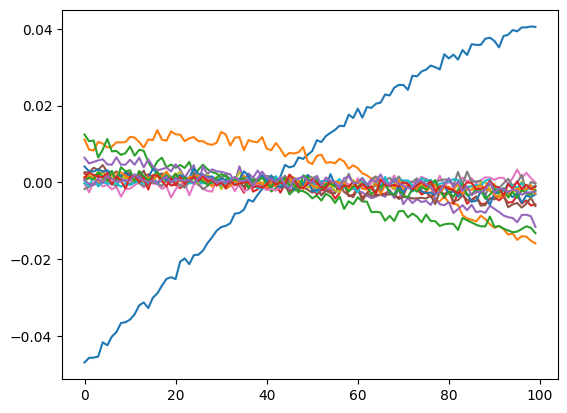

In [40]:
plt.plot(TRAJ_DIST)
TRAJ_DIST[0]

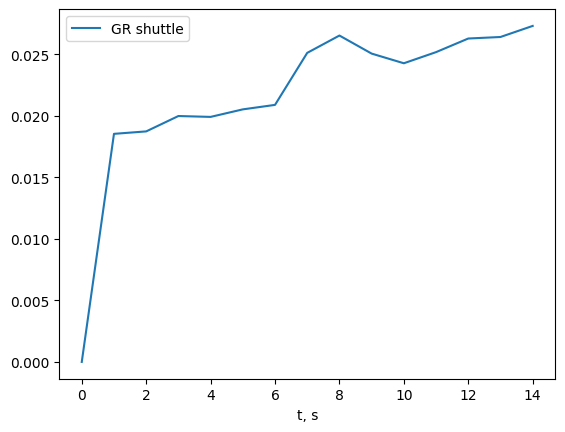

In [18]:
plt.plot(np.array(THETA_EST)[:, 0], label = "GR shuttle")
# plt.plot(np.rad2deg(np.array(THETA_EST)[:, 1]), label = "bias*1e2")
plt.xlabel("t, s")
# plt.ylim(0, 100)
plt.legend()
# plt.plot(np.array(MEAN_PARAM))

In [17]:
len(MEAN_PARAM), len(THETA_EST)

(400, 400)

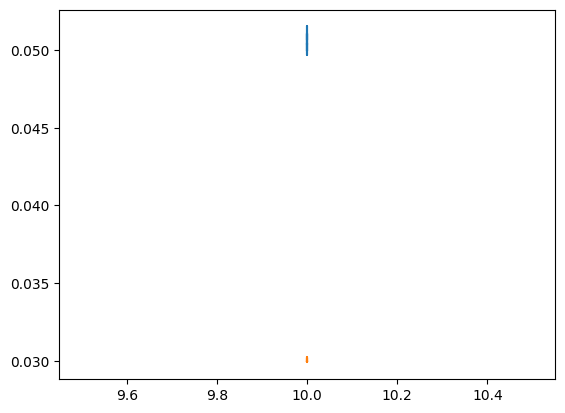

In [26]:
plt.plot(np.array(MEAN_PARAM), np.array(THETA_EST))

In [31]:
# get solution
# yref_0 = np.zeros((2*nx + nx_augmented, ))
# yref_0[:nx] = simY[0, :]
# yref_0[2*nx:] = np.array([0])
# acados_solver_mhe.set(0, "yref", yref_0)
# acados_solver_mhe.set(0, "p", simU[0,:])

# # set initial guess to x0_bar
# acados_solver_mhe.set(0, "x", x0_bar)
# yref = np.zeros((2*nx, ))

simXest, simWest, sim_param_est = get_estimated_data(acados_solver_mhe)